In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
import glob
import pandas as pd
import random

# **Read Dataset**

In [3]:
train_df_res = pd.read_csv('drive/MyDrive/Colab Notebooks/Estimates/train_data.csv')
test_df_res = pd.read_csv('drive/MyDrive/Colab Notebooks/Estimates/test_df_res.csv')

In [ ]:
# Multiplying risk factor by 100 to make it an integer

In [ ]:
test_df_res["Risk_factor_int"] = (test_df_res["Risk_factor"]*100).astype(int)

In [ ]:
train_df_res["Risk_factor_int"] = (train_df_res["Risk_factor"]*100).astype(int)

In [ ]:
test_df_res.shape

(644, 22)

In [ ]:
train_df_res.shape

(5791, 22)

In [ ]:
test_df_res.head(3)

,Unnamed: 0.1,Unnamed: 0,Task_name,Task_description,Task_label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,...,Pessimistic,Weighted_average,Standard_deviation,Risk_factor,Standard_confidence,High_confidence,Higher_confidence,Highest_confidence,Final_estimate,Variance
0,2436,2262,[New Containers] Remove input/process dotted l...,Right now the flow container has a dashed line...,EST_BE,Medium,INT Sprint 1,16,16,15,...,16,15.83,0.17,0.01,15.83,15.92,16.05,16.23,15,6561
1,3361,3187,Studio support for new OAuth configuration,"As a Studio user, I will like to have support ...",EST_BE,Medium,INT Sprint 1,4,5,3,...,4,3.83,0.17,0.04,3.83,3.92,4.05,4.23,3,441
2,233,59,"migrate items from 562 get error dialog popup,...","1. start 562 tac, on configuration page select...",EST_BE,Medium,INT Sprint 1,4,4,3,...,5,4.00,0.33,0.08,4.00,4.17,4.42,4.77,4,729


In [ ]:
train_df_res.head(3)

,Unnamed: 0.1,Unnamed: 0,Task_name,Task_description,Task_label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,...,Weighted_average,Standard_deviation,Risk_factor,Standard_confidence,High_confidence,Higher_confidence,Highest_confidence,Final_estimate,Variance,Risk_factor_int
0,2577,2403,Document OOTB available ${xd.???} keys,"As a consequence of not fixing XD-1289, we sho...",EST_BE,Medium,INT Sprint 1,8,9,7,...,8.00,0.33,0.04,8.00,8.17,8.42,8.77,8,2209,4
1,3433,3259,xd-container should start even if xd-admin is ...,currently xd-container will not start due to a...,EST_BE,Medium,INT Sprint 1,4,4,3,...,4.00,0.33,0.08,4.00,4.17,4.42,4.77,4,729,8
2,3011,2837,Allow easier detection when hook signature cha...,"Currently, if the signature of a hook function...",EST_BE,Medium,INT Sprint 1,4,5,3,...,3.83,0.17,0.04,3.83,3.92,4.05,4.23,3,441,4


## **One Hot Encoding**

In [4]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

Features

In [5]:
#Task_label
tl_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
tl_train = train_df_res["Task_label"].to_numpy().reshape(-1,1)
tl_test = test_df_res["Task_label"].to_numpy().reshape(-1,1)
tl_enc.fit(tl_train)
len_tl_enc = tl_enc.categories_[0].shape
print(len_tl_enc)

tl_train = tl_enc.transform(tl_train)
tl_test = tl_enc.transform(tl_test)
print(tl_train.shape, tl_test.shape)

(4,)
(5791, 4) (644, 4)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [6]:
#Planned_estimate
pe_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
pe_train = train_df_res["Planned_estimate"].to_numpy().reshape(-1,1)
pe_test = test_df_res["Planned_estimate"].to_numpy().reshape(-1,1)
pe_enc.fit(pe_train)
len_pe_enc = pe_enc.categories_[0].shape
print(len_pe_enc)

pe_train = pe_enc.transform(pe_train)
pe_test = pe_enc.transform(pe_test)
print(pe_train.shape, pe_test.shape)

(15,)
(5791, 15) (644, 15)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [7]:
#Final_estimate
fe_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
fe_train = train_df_res["Final_estimate"].to_numpy().reshape(-1,1)
fe_test = test_df_res["Final_estimate"].to_numpy().reshape(-1,1)
fe_enc.fit(fe_train)
len_fe_enc = fe_enc.categories_[0].shape
print(len_fe_enc)

fe_train = fe_enc.transform(fe_train)
fe_test = fe_enc.transform(fe_test)
print(fe_train.shape, fe_test.shape)

(28,)
(5791, 28) (644, 28)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Label

In [8]:
#Actual_estimate
ae_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
ae_train = train_df_res["Actual_estimate"].to_numpy().reshape(-1,1)
ae_test = test_df_res["Actual_estimate"].to_numpy().reshape(-1,1)
ae_enc.fit(ae_train)
len_ae_enc = ae_enc.categories_[0].shape
print(len_ae_enc)

ae_train = ae_enc.transform(ae_train)
ae_test = ae_enc.transform(ae_test)
print(ae_train.shape, ae_test.shape)

(26,)
(5791, 26) (644, 26)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


## **Gpt-2 tokenizer & pre-trained model**

In [9]:
import tensorflow as tf

In [10]:
from transformers import GPT2Tokenizer, TFGPT2Model

In [11]:
class GPT:
    def __init__(self):
        self.tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        self.model = TFGPT2Model.from_pretrained('gpt2')

    def inp_vector(self, inp):
        encoded_inp = self.tokenizer(inp, return_tensors='tf')
        out = self.model(encoded_inp)
        vector = out[0].numpy()[0]
        return np.mean(vector, axis=0)

    def vectors(self, inps):
        feat_vectors = []
        for i in inps:
            if type(i) != 'str':
                i = "NA"
            feat_vectors.append(self.inp_vector(i))
        return np.array(feat_vectors)

gpt_model = GPT()

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:72: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFGPT2Model.

All the weights of TFGPT2Model were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFGPT2Model for predictions without further training.


## **Features Encoding**

In [ ]:
# No need to calculate embeddings again if dataset is not changed. Load embeddings from below

Task Name

In [ ]:
# training embeddings
tn_train = gpt_model.vectors(train_df_res["Task_name"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/task_name_train.npy', tn_train)
print(type(tn_train))
print(tn_train.shape)

In [ ]:
# testing embeddings
tn_test = gpt_model.vectors(test_df_res["Task_name"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/task_name_test.npy', tn_test)
print(type(tn_test))
print(tn_test.shape)

Task description

In [ ]:
# training embeddings
td_train = gpt_model.vectors(train_df_res["Task_description"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/task_desc_train.npy', td_train)
print(type(td_train))
print(td_train.shape)

In [ ]:
# testing embeddings
td_test = gpt_model.vectors(test_df_res["Task_description"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/task_desc_test.npy', td_test)
print(type(td_test))
print(td_test.shape)

## Load features

In [ ]:
# Use this one

In [12]:
# Load feature encodings - Task name, task description, task label, planned estimate & final estimate
tn_train = np.load('drive/MyDrive/Colab Notebooks/Estimates/task_name_train.npy')
tn_test = np.load('drive/MyDrive/Colab Notebooks/Estimates/task_name_test.npy')

td_train = np.load('drive/MyDrive/Colab Notebooks/Estimates/task_desc_train.npy')
td_test = np.load('drive/MyDrive/Colab Notebooks/Estimates/task_desc_test.npy')

## **Define NN Architecture**

In [13]:
# Branch-1 Task name
inp1 = tf.keras.Input(shape=(768,), dtype=tf.int32, name="input_layer_1")
lay1 = tf.keras.layers.Dense(128, activation='relu')(inp1)

# Branch-2 Task description
inp2 = tf.keras.Input(shape=(768,), dtype=tf.int32, name="input_layer_2")
lay2 = tf.keras.layers.Dense(128, activation='relu')(inp2)

# Branch-3 Task label
inp3 = tf.keras.Input(shape=(4,), dtype=tf.int32, name="input_layer_3")
lay3 = tf.keras.layers.Dense(4, activation='relu')(inp3)

# Branch-4 Planned estimate
inp4 = tf.keras.Input(shape=(15,), dtype=tf.int32, name="input_layer_4")
lay4 = tf.keras.layers.Dense(16, activation='relu')(inp4)

# Branch-5 Final estimate
inp5 = tf.keras.Input(shape=(28,), dtype=tf.int32, name="input_layer_5")
lay5 = tf.keras.layers.Dense(32, activation='relu')(inp5)


# Concatenate Branch
out = tf.keras.layers.Concatenate()([lay1, lay2, lay3, lay4, lay5])
out = tf.keras.layers.Dense(384, activation='relu')(out)
out = tf.keras.layers.Dense(128, activation='relu')(out)
out = tf.keras.layers.Dense(26, activation='softmax')(out)

model = tf.keras.models.Model(inputs=[inp1, inp2, inp3, inp4, inp5], outputs=out)

In [14]:
model.compile(tf.keras.optimizers.Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer_1 (InputLayer)  [(None, 768)]                0         []                            
                                                                                                  
 input_layer_2 (InputLayer)  [(None, 768)]                0         []                            
                                                                                                  
 input_layer_3 (InputLayer)  [(None, 4)]                  0         []                            
                                                                                                  
 input_layer_4 (InputLayer)  [(None, 15)]                 0         []                            
                                                                                              

In [15]:
checkpoint = tf.keras.callbacks.ModelCheckpoint('drive/MyDrive/Colab Notebooks/Estimates/Model6/model6_5/model6_5.h5', monitor='loss', save_best_only=True, verbose=1)

## **Model Training**

In [16]:
train_sh = model.fit(
    [tn_train, td_train, tl_train, pe_train, fe_train], ae_train,
    epochs=300,
    callbacks=[checkpoint],
    validation_data=([tn_test, td_test, tl_test, pe_test, fe_test], ae_test),
    batch_size=16,
    verbose=1
)

Epoch 1/300
362/362 [==============================] - ETA: 0s - loss: 1.5313 - accuracy: 0.3965
Epoch 1: loss improved from inf to 1.53126, saving model to drive/MyDrive/Colab Notebooks/Estimates/Model6/model6_5/model6_5.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


362/362 [==============================] - 8s 9ms/step - loss: 1.5313 - accuracy: 0.3965 - val_loss: 0.9883 - val_accuracy: 0.4643
Epoch 2/300
361/362 [============================>.] - ETA: 0s - loss: 0.8873 - accuracy: 0.4932
Epoch 2: loss improved from 1.53126 to 0.88683, saving model to drive/MyDrive/Colab Notebooks/Estimates/Model6/model6_5/model6_5.h5
362/362 [==============================] - 3s 8ms/step - loss: 0.8868 - accuracy: 0.4932 - val_loss: 0.8530 - val_accuracy: 0.4969
Epoch 3/300
358/362 [============================>.] - ETA: 0s - loss: 0.8162 - accuracy: 0.5206
Epoch 3: loss improved from 0.88683 to 0.81609, saving model to drive/MyDrive/Colab Notebooks/Estimates/Model6/model6_5/model6_5.h5
362/362 [==============================] - 4s 10ms/step - loss: 0.8161 - accuracy: 0.5206 - val_loss: 0.8225 - val_accuracy: 0.5062
Epoch 4/300
358/362 [============================>.] - ETA: 0s - loss: 0.7911 - accuracy: 0.4993
Epoch 4: loss improved from 0.81609 to 0.79181, sav

In [17]:
print(train_sh.history)
model.save('drive/MyDrive/Colab Notebooks/Estimates/Model6/model6_5/model6_5.h5')
results = model.evaluate([tn_test, td_test, tl_test, pe_test, fe_test], ae_test, batch_size=16)

predictions = model.predict([tn_test, td_test, tl_test, pe_test, fe_test])

print(predictions.shape)
print(ae_test.shape)

y_actual_label = test_df_res["Actual_estimate"]
y_pred_label = ae_enc.inverse_transform(predictions)
print(y_actual_label.shape, y_pred_label.shape)

test_df_res['Ai_estimate'] = y_pred_label
test_df_res.head(10)

{'loss': [1.5312596559524536, 0.8868283629417419, 0.816092312335968, 0.7918065786361694, 0.7755841612815857, 0.7597420811653137, 0.7489213347434998, 0.7442482113838196, 0.7393592596054077, 0.7355208992958069, 0.7346847057342529, 0.7292550206184387, 0.7273238301277161, 0.7282190918922424, 0.7213431596755981, 0.7243227958679199, 0.7199986577033997, 0.7201162576675415, 0.7209129929542542, 0.719568133354187, 0.7205491065979004, 0.7168132066726685, 0.7180655002593994, 0.716521680355072, 0.7172426581382751, 0.7154804468154907, 0.7136815190315247, 0.7140089869499207, 0.714438796043396, 0.7118080854415894, 0.712519645690918, 0.7136356234550476, 0.7135241031646729, 0.7141419649124146, 0.7134935855865479, 0.711759090423584, 0.7109982371330261, 0.7119577527046204, 0.7108035087585449, 0.710509181022644, 0.7112201452255249, 0.7101638317108154, 0.7108461260795593, 0.7099959254264832, 0.7099222540855408, 0.7098320722579956, 0.709989607334137, 0.7091437578201294, 0.710478663444519, 0.7094171047210693,

,Unnamed: 0.1,Unnamed: 0,Task_name,Task_description,Task_label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,...,Weighted_average,Standard_deviation,Risk_factor,Standard_confidence,High_confidence,Higher_confidence,Highest_confidence,Final_estimate,Variance,Ai_estimate
0,2436,2262,[New Containers] Remove input/process dotted l...,Right now the flow container has a dashed line...,EST_BE,Medium,INT Sprint 1,16,16,15,...,15.83,0.17,0.01,15.83,15.92,16.05,16.23,15,6561,17
1,3361,3187,Studio support for new OAuth configuration,"As a Studio user, I will like to have support ...",EST_BE,Medium,INT Sprint 1,4,5,3,...,3.83,0.17,0.04,3.83,3.92,4.05,4.23,3,441,4
2,233,59,"migrate items from 562 get error dialog popup,...","1. start 562 tac, on configuration page select...",EST_BE,Medium,INT Sprint 1,4,4,3,...,4.00,0.33,0.08,4.00,4.17,4.42,4.77,4,729,4
3,3667,3493,Allow extensions code to be splitted in severa...,As described in the execution section of the s...,EST_BE,Medium,INT Sprint 1,16,16,15,...,15.83,0.17,0.01,15.83,15.92,16.05,16.23,15,6561,17
4,5011,4837,HdfsMongoDB Job failing due because of missing...,Looks to have been introduced by https://githu...,EST_BE,Medium,INT Sprint 1,6,6,5,...,6.00,0.33,0.06,6.00,6.17,6.42,6.77,6,1369,7
5,4850,4676,Rename controllers to have pluralized named (e...,See implementation used for Steams and apply t...,EST_BE,Medium,INT Sprint 1,2,2,1,...,1.83,0.17,0.09,1.83,1.92,2.05,2.23,1,121,3
6,3891,3717,Reproducing errors of the current obs_decam pa...,Learning the stack and development worlflow by...,EST_BE,Medium,INT Sprint 1,4,5,3,...,4.00,0.33,0.08,4.00,4.17,4.42,4.77,4,729,4
7,1699,1525,Week end 1/23/16,"Support for lsst-dev cluster, OpenStack, and a...",EST_BE,Medium,INT Sprint 1,4,5,3,...,3.83,0.17,0.04,3.83,3.92,4.05,4.23,3,441,4
8,2742,2568,Ruby: Problem formatting Ruby source code wher...,ctrl-shift-f can't format source code of the a...,EST_BE,Medium,INT Sprint 1,16,17,15,...,16.00,0.33,0.02,16.00,16.17,16.42,16.77,16,7569,16
9,1703,1529,Unify connectors and endpoints part 2,Need to finish implementation of https://docs....,EST_BE,Medium,INT Sprint 1,16,17,15,...,16.00,0.33,0.02,16.00,16.17,16.42,16.77,16,7569,16


In [18]:
test_df_res.drop(test_df_res.columns[[0, 1]], axis=1, inplace=True)

In [19]:
test_df_res.head(3)

,Task_name,Task_description,Task_label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,Most_likely,Pessimistic,Weighted_average,Standard_deviation,Risk_factor,Standard_confidence,High_confidence,Higher_confidence,Highest_confidence,Final_estimate,Variance,Ai_estimate
0,[New Containers] Remove input/process dotted l...,Right now the flow container has a dashed line...,EST_BE,Medium,INT Sprint 1,16,16,15,16,16,15.83,0.17,0.01,15.83,15.92,16.05,16.23,15,6561,17
1,Studio support for new OAuth configuration,"As a Studio user, I will like to have support ...",EST_BE,Medium,INT Sprint 1,4,5,3,4,4,3.83,0.17,0.04,3.83,3.92,4.05,4.23,3,441,4
2,"migrate items from 562 get error dialog popup,...","1. start 562 tac, on configuration page select...",EST_BE,Medium,INT Sprint 1,4,4,3,4,5,4.00,0.33,0.08,4.00,4.17,4.42,4.77,4,729,4


In [20]:
test_df_res.to_csv('drive/MyDrive/Colab Notebooks/Estimates/Model6/model6_5/Model6_5_results.csv')

Text(0, 0.5, 'AI estimate')

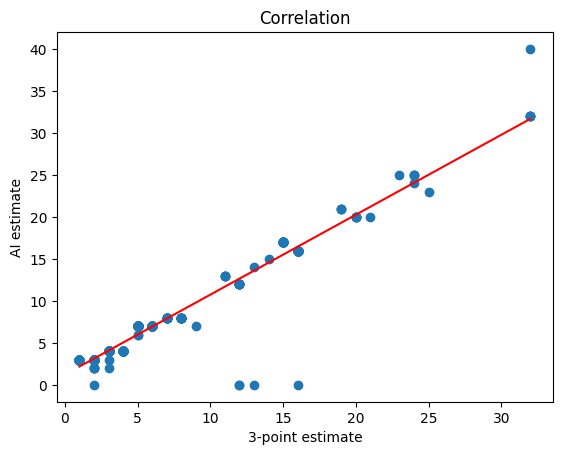

In [21]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

y = test_df_res['Ai_estimate']
x = test_df_res['Final_estimate']
correlation = y.corr(x)
correlation

# adds the title
plt.title('Correlation')

# plot the data
plt.scatter(x, y)

# fits the best fitting line to the data
plt.plot(np.unique(x),
		np.poly1d(np.polyfit(x, y, 1))
		(np.unique(x)), color='red')

# Labelling axes
plt.xlabel('3-point estimate')
plt.ylabel('AI estimate')

In [22]:
# prepare testing data

In [23]:
df_test = pd.read_csv('drive/MyDrive/Colab Notebooks/Estimates/test_data.csv')

In [24]:
df_test.shape

(21, 7)

In [25]:
df_test.head(3)


,Task_name,Task_description,Task_label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate
0,Set up JDK and integrate with backend,Setting up the Java Development Kit in the pro...,EST_BE,Medium,ET Sprint 4,16,16
1,Set up environment and install packages,Setting up Python environment in AWS EC-2 Inst...,EST_INFRA,Medium,ET Sprint 4,4,4
2,"Create data preprocessing, feature engineering...",Data preprocessing - Data cleaning and transfo...,EST_AI,Medium,ET Sprint 4,8,9


In [26]:
import numpy as np

In [27]:
df_test["Optimistic"] = df_test["Planned_estimate"] + np.random.randint(0, 1, df_test.shape[0])
df_test["Most_likely"] = df_test["Planned_estimate"] + np.random.randint(0, 2, df_test.shape[0])
df_test["Pessimistic"] = df_test["Planned_estimate"] + np.random.randint(0, 3, df_test.shape[0])

In [28]:
df_test["Weighted_average"] = round(((df_test["Optimistic"] + (4*df_test["Most_likely"]) + df_test["Pessimistic"])/6), 2)
df_test["Standard_deviation"] = round(((df_test["Pessimistic"] - df_test["Optimistic"])/6), 2)
df_test["Risk_factor"] = round((df_test["Standard_deviation"]/df_test["Weighted_average"]), 2)
df_test["Standard_confidence"] = df_test["Weighted_average"]
df_test["High_confidence"] = round((df_test["Weighted_average"] + (0.53 * df_test["Standard_deviation"])), 2)
df_test["Higher_confidence"] = round((df_test["Weighted_average"] + (1.28 * df_test["Standard_deviation"])), 2)
df_test["Highest_confidence"] = round((df_test["Weighted_average"] + (2.33 * df_test["Standard_deviation"])), 2)
df_test["Final_estimate"] = round((df_test["Highest_confidence"]), 1)
df_test["Variance"] = round(((6*df_test["Pessimistic"] - df_test["Optimistic"])**2), 2)
df_test['Final_estimate'] = np.where((df_test['Risk_factor'] >= 0) & (df_test['Risk_factor'] <= 0.05), df_test['Standard_confidence'], df_test['Final_estimate'])
df_test['Final_estimate'] = np.where((df_test['Risk_factor'] > 0.05) & (df_test['Risk_factor'] <= 0.1), df_test['High_confidence'], df_test['Final_estimate'])
df_test['Final_estimate'] = np.where((df_test['Risk_factor'] > 0.1) & (df_test['Risk_factor'] <= 0.15), df_test['Higher_confidence'], df_test['Final_estimate'])
df_test["Final_estimate"] = df_test["Final_estimate"].astype(int)
df_test["Risk_factor_int"] = (df_test["Risk_factor"]*100).astype(int)


In [29]:
df_test.to_csv('drive/MyDrive/Colab Notebooks/Estimates/Model6/model6_5/test_data_complete.csv')

In [30]:
### Start

In [31]:
# need to change this
df_test = pd.read_csv('drive/MyDrive/Colab Notebooks/Estimates/Model6/model6_5/test_data_complete.csv')

In [32]:
df_test.shape

(21, 21)

In [33]:
df_test.head(3)

,Unnamed: 0,Task_name,Task_description,Task_label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,Most_likely,...,Weighted_average,Standard_deviation,Risk_factor,Standard_confidence,High_confidence,Higher_confidence,Highest_confidence,Final_estimate,Variance,Risk_factor_int
0,0,Set up JDK and integrate with backend,Setting up the Java Development Kit in the pro...,EST_BE,Medium,ET Sprint 4,16,16,16,16,...,16.0,0.00,0.00,16.0,16.00,16.00,16.00,16,6400,0
1,1,Set up environment and install packages,Setting up Python environment in AWS EC-2 Inst...,EST_INFRA,Medium,ET Sprint 4,4,4,4,5,...,5.0,0.33,0.07,5.0,5.17,5.42,5.77,5,1024,7
2,2,"Create data preprocessing, feature engineering...",Data preprocessing - Data cleaning and transfo...,EST_AI,Medium,ET Sprint 4,8,9,8,9,...,9.0,0.33,0.04,9.0,9.17,9.42,9.77,9,2704,4


In [34]:
# Testing data encodings
tn_testdata = gpt_model.vectors(df_test["Task_name"])
print(type(tn_testdata))
print(tn_testdata.shape)

td_testdata = gpt_model.vectors(df_test["Task_description"])
print(type(td_testdata))
print(td_testdata.shape)

tl_testdata = df_test["Task_label"].to_numpy().reshape(-1,1)
tl_testdata = tl_enc.transform(tl_testdata)
print(tl_testdata.shape)

pe_testdata = df_test["Planned_estimate"].to_numpy().reshape(-1,1)
pe_testdata = pe_enc.transform(pe_testdata)
print(pe_testdata.shape)

fe_testdata = df_test["Final_estimate"].to_numpy().reshape(-1,1)
fe_testdata = fe_enc.transform(fe_testdata)
print(fe_testdata.shape)


<class 'numpy.ndarray'>
(21, 768)
<class 'numpy.ndarray'>
(21, 768)
(21, 4)
(21, 15)
(21, 28)


In [35]:
import tensorflow as tf

In [36]:
model6 = tf.keras.models.load_model('drive/MyDrive/Colab Notebooks/Estimates/Model6/model6_5/model6_5.h5')
model6.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer_1 (InputLayer)  [(None, 768)]                0         []                            
                                                                                                  
 input_layer_2 (InputLayer)  [(None, 768)]                0         []                            
                                                                                                  
 input_layer_3 (InputLayer)  [(None, 4)]                  0         []                            
                                                                                                  
 input_layer_4 (InputLayer)  [(None, 15)]                 0         []                            
                                                                                              

In [ ]:
### Not required

In [ ]:
from sklearn.preprocessing import OneHotEncoder

train_df_res = pd.read_csv('drive/MyDrive/Colab Notebooks/Estimates/train_data.csv')
test_df_res = pd.read_csv('drive/MyDrive/Colab Notebooks/Estimates/test_df_res.csv')

#Actual_estimate
ae_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
ae_train = train_df_res["Actual_estimate"].to_numpy().reshape(-1,1)
ae_test = test_df_res["Actual_estimate"].to_numpy().reshape(-1,1)
ae_enc.fit(ae_train)
len_ae_enc = ae_enc.categories_[0].shape
print(len_ae_enc)

ae_train = ae_enc.transform(ae_train)
ae_test = ae_enc.transform(ae_test)
print(ae_train.shape, ae_test.shape)

(26,)
(5791, 26) (644, 26)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [37]:
ae_testdata = df_test["Actual_estimate"].to_numpy().reshape(-1,1)
ae_testdata = ae_enc.transform(ae_testdata)
print(ae_testdata.shape)

(21, 26)


In [38]:
predictions = model6.predict([tn_testdata, td_testdata, tl_testdata, pe_testdata, fe_testdata])

print(predictions.shape)
print(ae_testdata.shape)

y_actual_label = df_test["Actual_estimate"]
y_pred_label = ae_enc.inverse_transform(predictions)

print(y_actual_label.shape, y_pred_label.shape)

df_test['Ai_estimate'] = y_pred_label

df_test.drop(df_test.columns[0], axis=1, inplace=True)

1/1 [==============================] - 0s 90ms/step
(21, 26)
(21, 26)
(21,) (21, 1)


In [39]:
df_test.to_csv('drive/MyDrive/Colab Notebooks/Estimates/Model6/model6_5/Model6_5results_testdata.csv')

In [40]:
df_test.head(3)

,Task_name,Task_description,Task_label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,Most_likely,Pessimistic,...,Standard_deviation,Risk_factor,Standard_confidence,High_confidence,Higher_confidence,Highest_confidence,Final_estimate,Variance,Risk_factor_int,Ai_estimate
0,Set up JDK and integrate with backend,Setting up the Java Development Kit in the pro...,EST_BE,Medium,ET Sprint 4,16,16,16,16,16,...,0.00,0.00,16.0,16.00,16.00,16.00,16,6400,0,16
1,Set up environment and install packages,Setting up Python environment in AWS EC-2 Inst...,EST_INFRA,Medium,ET Sprint 4,4,4,4,5,6,...,0.33,0.07,5.0,5.17,5.42,5.77,5,1024,7,4
2,"Create data preprocessing, feature engineering...",Data preprocessing - Data cleaning and transfo...,EST_AI,Medium,ET Sprint 4,8,9,8,9,10,...,0.33,0.04,9.0,9.17,9.42,9.77,9,2704,4,7


Text(0, 0.5, 'AI estimate')

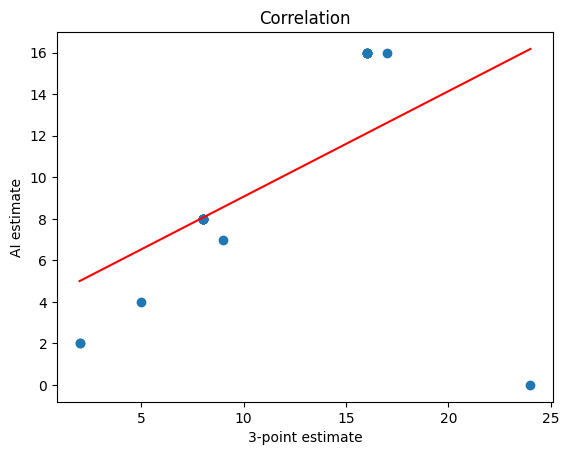

In [41]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

y = df_test['Ai_estimate']
x = df_test['Final_estimate']
correlation = y.corr(x)
correlation

# adds the title
plt.title('Correlation')

# plot the data
plt.scatter(x, y)

# fits the best fitting line to the data
plt.plot(np.unique(x),
		np.poly1d(np.polyfit(x, y, 1))
		(np.unique(x)), color='red')

# Labelling axes
plt.xlabel('3-point estimate')
plt.ylabel('AI estimate')

Text(0, 0.5, 'AI estimate')

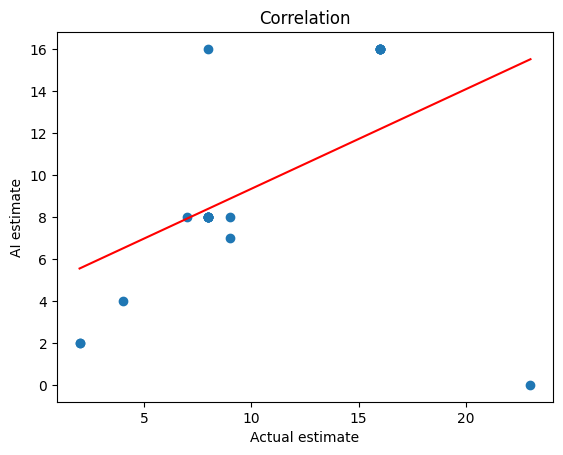

In [42]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

y = df_test['Ai_estimate']
x = df_test['Actual_estimate']
correlation = y.corr(x)
correlation

# adds the title
plt.title('Correlation')

# plot the data
plt.scatter(x, y)

# fits the best fitting line to the data
plt.plot(np.unique(x),
		np.poly1d(np.polyfit(x, y, 1))
		(np.unique(x)), color='red')

# Labelling axes
plt.xlabel('Actual estimate')
plt.ylabel('AI estimate')